In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import umap
import umap.plot
import sys
ROOT = Path.cwd().parent.parent
sys.path.append(str(ROOT))
from src.stream_3.gen_hdb_clus import GenerateHDBSCAN
from src.stream_3.gen_umap_emb import GenerateUmapEmb
from src.loading_data.load_data import get_master_data

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\fergu\Do

In [2]:
df = get_master_data()

Data loaded with zero missing values.


In [3]:
df.columns

Index(['serial', 'year', 'LCA_Class', 'Age9', 'Gend3', 'Eth7', 'Disab2_POP',
       'Educ6', 'NSSEC5', 'IMD10', 'WorkStat8', 'Child4', 'HHLiv9',
       'motivd_POP', 'MEMS7_ALL', 'active'],
      dtype='str')

In [4]:
path = r'C:\Users\fergu\Documents\GitHub\london_sport2\data\master_data\2016_to_2023_full_preprocessed_data_set.csv.gz'
old = pd.read_csv(path, usecols = ['serial', 'year', 'Motiva_POP'])
combined = df.merge(old, how='left', on=['serial', 'year'])

In [5]:
combined.columns

Index(['serial', 'year', 'LCA_Class', 'Age9', 'Gend3', 'Eth7', 'Disab2_POP',
       'Educ6', 'NSSEC5', 'IMD10', 'WorkStat8', 'Child4', 'HHLiv9',
       'motivd_POP', 'MEMS7_ALL', 'active', 'Motiva_POP'],
      dtype='str')

In [6]:
drop_vars = ['serial', 'year', 'LCA_Class', 'MEMS7_ALL', 'active']
main_vars = [var for var in combined.columns if var not in drop_vars]
main_combined = combined[main_vars]

In [7]:
main_combined.columns

Index(['Age9', 'Gend3', 'Eth7', 'Disab2_POP', 'Educ6', 'NSSEC5', 'IMD10',
       'WorkStat8', 'Child4', 'HHLiv9', 'motivd_POP', 'Motiva_POP'],
      dtype='str')

In [8]:
umap_emb = GenerateUmapEmb(main_combined)
umap_instance = umap_emb.fit_fuzzy_umap()

Categorical Columns for UMAP:
 ['Gend3', 'Eth7', 'Disab2_POP', 'WorkStat8', 'HHLiv9']
Continuous Columns for UMAP
['Age9', 'Educ6', 'NSSEC5', 'IMD10', 'Child4', 'motivd_POP', 'Motiva_POP']
Continuous Shape: (85013, 7)
Categorical Shape: (85013, 29)
Finished fitting continuous....


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for dice distance metric; inverse_transform will be unavailable
  warn(


Finished fitting categorical....
Finished computing intersection...
UMAP fit complete!


<Axes: >

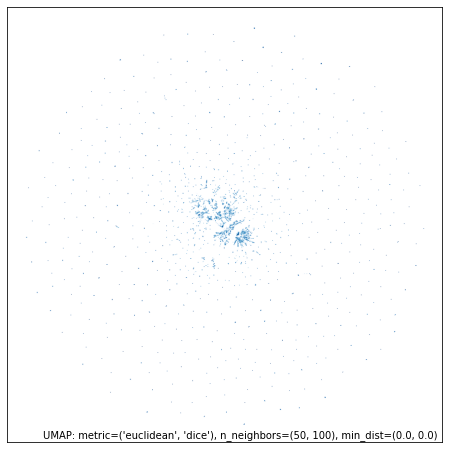

In [9]:
umap.plot.points(umap_instance)

In [10]:

x = list(old.columns)